In [ ]:
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_chroma import Chroma
from dotenv import load_dotenv

load_dotenv()

# ============================================================================
# LLM & VECTOR STORE SETUP
# ============================================================================
# Ollama LLM with Qwen3
llm = ChatOllama(
    model="qwen3:1.7b", 
    base_url="http://localhost:11434"
)

# Ollama Embeddings
embeddings = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

# Chroma Vector Store (assumes data already exists from previous code)
vector_store = Chroma(
    collection_name="pdf_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_db"
)

print("✓ Using Ollama qwen3:1.7b + bge-m3")
print(f"✓ Connected to existing Chroma vector store ({vector_store._collection.count()} documents)")

In [2]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-06-14T23:36:59.649677947Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4835668946, 'load_duration': 1498969228, 'prompt_eval_count': 11, 'prompt_eval_duration': 170071000, 'eval_count': 95, 'eval_duration': 3063791439, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019ec87e-d11b-7ab2-9aa3-94f75cfb53d7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 95, 'total_tokens': 106})

In [4]:
# ============================================================================
# VECTOR STORE VERIFICATION
# ============================================================================
print("\n🔍 Testing Vector Store Connection...")

# Test 1: Check collection info
collection = vector_store._collection
doc_count = collection.count()
print(f"✓ Collection '{collection.name}' found with {doc_count} documents")


# Test 2: Sample similarity search
test_query = "methodology"
results = vector_store.similarity_search(test_query, k=3)
print(f"\n✓ Sample search for '{test_query}':")
for i, doc in enumerate(results, 1):
    print(f"  {i}. Page {doc.metadata.get('page', '?')}: {doc.page_content[:100]}...")


🔍 Testing Vector Store Connection...
✓ Collection 'pdf_collection' found with 593 documents

✓ Sample search for 'methodology':
  1. Page 60: This method could lead to biased or incomplete feedback due to the diversity of opinions
among label...
  2. Page 59: involves providing accurate information and transparency about the model’s uncertainty and
limitatio...
  3. Page 103: Method Non-football (DROP) Football (DROP) GSM8k
Zero-Shot 43.86 51.77 16.38
Standard Prompting 58.7...


In [5]:
# ============================================================================
# RETRIEVAL TOOL
# ============================================================================
@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """Retrieve relevant information from the document to answer the query."""
    print(f"🔍 Searching: '{query}'")
    
    # Perform similarity search
    docs = vector_store.similarity_search(query, k=4)
    
    # Format for LLM
    content = "\n\n".join(
        f"Page {doc.metadata.get('page', '?')}: {doc.page_content}" 
        for doc in docs
    )
    
    print(f"✓ Found {len(docs)} relevant chunks")
    return content, docs

# ============================================================================
# AGENT CREATION
# ============================================================================
# Tools for the agent (single tool only)
tools = [retrieve_context]

# Agent prompt - simplified for single tool
prompt = """You are a research assistant with a document retrieval tool.

Tool:
- retrieve_context: Search the document for relevant information

Always use the tool to find relevant information before answering.
Cite page numbers and be thorough."""

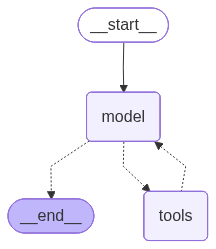

In [8]:
# Create the agentic RAG
rag_agent = create_agent(llm, tools, system_prompt=prompt)

rag_agent

In [9]:
response = rag_agent.invoke({'messages': "What are the main methods mentioned in this paper?"})

🔍 Searching: 'main methods in this paper'
✓ Found 4 relevant chunks


In [10]:
response

{'messages': [HumanMessage(content='What are the main methods mentioned in this paper?', additional_kwargs={}, response_metadata={}, id='80bab08d-ceba-4aab-906b-8032a86572f8'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:0.6b', 'created_at': '2026-06-14T23:44:21.953310397Z', 'done': True, 'done_reason': 'stop', 'total_duration': 11667634075, 'load_duration': 1239598666, 'prompt_eval_count': 193, 'prompt_eval_duration': 413641016, 'eval_count': 295, 'eval_duration': 9743322843, 'logprobs': None, 'model_name': 'qwen3:0.6b', 'model_provider': 'ollama'}, id='lc_run--019ec885-762b-7d81-aae4-08272dea9512-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'main methods in this paper'}, 'id': 'c905e3e9-10cb-41a7-8ff9-863cea993028', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 193, 'output_tokens': 295, 'total_tokens': 488}),
  ToolMessage(content='Page 142: requires manual calculation and cannot be solved using P

In [11]:
# ============================================================================
# QUERY FUNCTION
# ============================================================================
def ask(question: str):
    """Ask the agentic RAG a question."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Show tool usage
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Show final answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [12]:
# ============================================================================
# TESTING
# ============================================================================
# Test basic retrieval
ask("What are the main methods mentioned in this paper?")


Question: What are the main methods mentioned in this paper?

💬 Answer:
What are the main methods mentioned in this paper?

🔧 Using: retrieve_context with {'query': 'main methods mentioned in this paper'}
🔍 Searching: 'main methods mentioned in this paper'
✓ Found 4 relevant chunks

💬 Answer:
Page 60: This method could lead to biased or incomplete feedback due to the diversity of opinions
among labellers and the neglect of unselected samples. To improve this, later studies
introduced the Elo rating system to establish a preference ranking by comparing outputs,
thereby providing a more nuanced training signal [165, 85].
• Question-based approach. This method involves labellers providing detailed feed-
back by answering specific questions designed to assess alignment criteria and additional
constraints. For example, in the WebGPT project, labellers evaluate the usefulness of
retrieved documents to answer given inputs, helping to filter and utilize relevant informa-
tion [124].
• Rule-ba

In [ ]:
# ============================================================================
# INTERACTIVE CHAT
# ============================================================================
def chat():
    """Start interactive chat with the agentic RAG."""
    print("\n🤖 Agentic RAG Chat - Type 'quit' to exit")
    
    while True:
        question = input("\nYour question: ").strip()
        if question.lower() in ['quit', 'exit', 'q']:
            break
        if question:
            ask(question)

chat()